# Argentina vs France — World Cup 2022 Final Dashboard
Cleaned-up, single version of the pipeline (duplicate/legacy cells removed).

If `statsbombpy` or `mplsoccer` aren't installed yet, uncomment and run the line below once.

In [52]:
# !pip install statsbombpy mplsoccer --quiet

import math
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from mplsoccer import VerticalPitch
from statsbombpy import sb

## 1. Load match data

In [53]:
df = sb.events(match_id=3869685).sort_values(by=['index'])

# Drop penalty-shootout events (period 5) — shot maps / xG flow should only cover
# regulation + extra time, matching the "PENALTIES EXCLUDED" note on the dashboard.
df = df[df.period < 5].copy()

## 2. Styling constants

In [54]:
ARGENTINA = "Argentina"
FRANCE = "France"

ARGENTINA_COLOR = "#1C86D9"   # more saturated sky blue -- pops against the green pitch
ARGENTINA_DARK = "#173F70"

FRANCE_COLOR = "#173F70"
FRANCE_LIGHT = "#6F8EAF"

TEXT = "#132743"
MUTED = "#718096"
LIGHT_TEXT = "#9AA5B1"
BORDER = "#D8E0E8"
GRID = "#E8EDF2"
PANEL = "#FBFCFE"
WHITE = "#FFFFFF"

PITCH_GREEN = "#5A9F5C"
PITCH_STRIPE = "#5FA862"
PITCH_LINE = "#F2F6F2"

## 3. Logos and figure size
Update `ARGENTINA_LOGO` / `FRANCE_LOGO` to point at real files on your machine (or leave them — `draw_team_logo` skips missing files instead of crashing).

In [55]:
# Point these at the same crest files you already used successfully in notebook1
# (e.g. "D:/Projects/FootballAnalysis1/images/argentina_logo.png"). Relative paths
# are resolved from wherever you launched Jupyter, so an absolute path is safer.
ARGENTINA_LOGO = "D:/Projects/FootballAnalysis1/images/argentina_logo.png"
FRANCE_LOGO = "D:/Projects/FootballAnalysis1/images/france_logo.png"

FIGSIZE = (16, 10)

## 4. Data-prep helpers

In [56]:
def _safe_location(value):
    """Return [x, y] from a StatsBomb location value."""
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        return [value[0], value[1]]
    return [float("nan"), float("nan")]


def prepare_events(df):
    """Prepare location and chronological fields."""
    df = df.copy()

    if "location" in df.columns:
        locations = df["location"].apply(_safe_location)
        df[["x", "y"]] = pd.DataFrame(
            locations.tolist(),
            index=df.index
        )

    if "minute" in df.columns and "second" in df.columns:
        df["match_second"] = (
            df["minute"].fillna(0) * 60 +
            df["second"].fillna(0)
        )

    return df


def get_team(df, team_name):
    return df[df["team"] == team_name].copy()


def get_shots(df, team_name, exclude_penalties=True):
    shots = df[
        (df["team"] == team_name) &
        (df["type"] == "Shot")
    ].copy()

    if exclude_penalties and "shot_type" in shots.columns:
        shots = shots[
            shots["shot_type"].fillna("") != "Penalty"
        ]

    return shots


def get_passes(df, team_name):
    return df[
        (df["team"] == team_name) &
        (df["type"] == "Pass")
    ].copy()


def team_stats(df, team_name):
    """Calculate headline statistics.

    Penalties taken during normal/extra time (periods 1-4) count as real
    shots/xG here -- only the penalty shootout (period 5) is out of play,
    and that's already dropped when df was loaded.
    """
    shots = get_shots(df, team_name, exclude_penalties=False)
    passes = get_passes(df, team_name)

    # StatsBomb successful passes normally have a null outcome.
    completed = passes["pass_outcome"].isna()

    # Standard event-level shot outcome definition.
    on_target = shots[
        shots["shot_outcome"].isin(
            ["Goal", "Saved", "Saved To Post"]
        )
    ]

    return {
        "xG": shots["shot_statsbomb_xg"].fillna(0).sum(),
        "shots": len(shots),
        "shots_on_target": len(on_target),
        "passes": len(passes),
        "pass_completion": (
            completed.mean() * 100
            if len(passes)
            else 0
        ),
    }

## 5. Layout helpers

In [57]:
def add_panel(fig, left, bottom, width, height, radius=0.012):
    """Add a subtle rounded panel behind an axes."""
    patch = FancyBboxPatch(
        (left, bottom),
        width,
        height,
        boxstyle=f"round,pad=0.004,rounding_size={radius}",
        transform=fig.transFigure,
        facecolor=WHITE,
        edgecolor=BORDER,
        linewidth=0.9,
        zorder=0
    )
    fig.patches.append(patch)


def add_section_title(ax, title, color=TEXT):
    ax.text(
        0.0, 1.035,
        title.upper(),
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=color,
        family="DejaVu Sans"
    )


def draw_team_logo(ax, image_path, x, y, zoom=0.12):
    """Draw a team crest if the file exists; otherwise warn instead of
    failing silently, so a bad path is easy to spot."""
    if not image_path:
        return

    if not os.path.exists(image_path):
        print(f"[draw_team_logo] logo not found, skipping: {image_path}")
        return

    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    image = plt.imread(image_path)
    artist = AnnotationBbox(
        OffsetImage(image, zoom=zoom),
        (x, y),
        xycoords="axes fraction",
        frameon=False
    )
    ax.add_artist(artist)

## 6. Pass network

In [58]:
def jersey_numbers(team_df):
    """Extract starting lineup jersey numbers if tactics are available."""
    result = []

    if "tactics" not in team_df.columns:
        return pd.DataFrame(
            columns=["player_id", "jersey_number"]
        )

    for tactic in team_df.loc[
        team_df["tactics"].notna(), "tactics"
    ]:
        if not isinstance(tactic, dict):
            continue

        for player in tactic.get("lineup", []):
            info = player.get("player", {})

            if (
                "id" in info and
                "jersey_number" in player
            ):
                result.append({
                    "player_id": info["id"],
                    "jersey_number": player["jersey_number"]
                })

    if not result:
        return pd.DataFrame(
            columns=["player_id", "jersey_number"]
        )

    return pd.DataFrame(result).drop_duplicates(
        "player_id"
    )


def draw_pass_network(ax, df, team_name, team_color):
    team_full = get_team(df, team_name).copy()

    # Jersey numbers live on Starting XI / Tactical Shift events, which have
    # no location — pull them before filtering those events out below.
    numbers = jersey_numbers(team_full)

    team = team_full[
        team_full["location"].notna()
    ].copy()

    if team.empty:
        return

    team["match_second"] = (
        team["minute"].fillna(0) * 60 +
        team["second"].fillna(0)
    )

    team = team.sort_values("match_second")

    # Approximate recipient identification from the next event.
    team["passer"] = team["player_id"]
    team["recipient"] = team["passer"].shift(-1)

    passes = team[
        (team["type"] == "Pass") &
        (team["pass_outcome"].isna())
    ].copy()

    if passes.empty:
        return

    # First-substitution cutoff.
    substitutions = team[
        team["type"] == "Substitution"
    ]

    first_sub = substitutions["match_second"].min()

    if not pd.isna(first_sub):
        first_sub = max(first_sub, 45 * 60)
        passes = passes[
            passes["match_second"] < first_sub
        ]

    # Player average positions and number of completed passes.
    locations = passes.groupby("passer").agg(
        x=("x", "mean"),
        y=("y", "mean"),
        count=("id", "count")
    )

    links = (
        passes.groupby(["passer", "recipient"])
        .size()
        .reset_index(name="pass_count")
    )

    links = links.merge(
        locations,
        left_on="passer",
        right_index=True
    )

    links = links.merge(
        locations,
        left_on="recipient",
        right_index=True,
        suffixes=("", "_end")
    )

    # Remove weak / noisy connections.
    links = links[
        links["pass_count"] >= 4
    ].copy()

    pitch = VerticalPitch(
        pitch_type="statsbomb",
        pitch_color=PITCH_GREEN,
        line_color=PITCH_LINE,
        linewidth=1.2,
        stripe=True,
        stripe_color=PITCH_STRIPE
    )
    pitch.draw(ax=ax)

    # Pass arrows.
    for _, row in links.iterrows():
        dx = row["x_end"] - row["x"]
        dy = row["y_end"] - row["y"]
        distance = math.hypot(dx, dy)

        if distance <= 0:
            continue

        # Shrink arrow endpoints so they stop before player circles.
        shrink = min(1.4, distance * 0.22)
        ux = dx / distance
        uy = dy / distance

        start_x = row["x"] + ux * shrink
        start_y = row["y"] + uy * shrink
        end_x = row["x_end"] - ux * shrink
        end_y = row["y_end"] - uy * shrink

        ax.annotate(
            "",
            xy=(end_y, end_x),
            xytext=(start_y, start_x),
            arrowprops=dict(
                arrowstyle="-|>",
                linewidth=min(
                    4.5,
                    0.8 + row["pass_count"] * 0.32
                ),
                color=team_color,
                alpha=0.65
            ),
            zorder=1
        )

    # Player nodes.
    sizes = 380 + locations["count"] * 3.5

    pitch.scatter(
        locations["x"],
        locations["y"],
        s=sizes,
        ax=ax,
        facecolor=WHITE,
        edgecolor=team_color,
        linewidth=1.7,
        zorder=4
    )

    # Jersey labels.
    for player_id, row in locations.iterrows():
        jersey = numbers.loc[
            numbers["player_id"] == player_id,
            "jersey_number"
        ].values

        label = (
            str(int(jersey[0]))
            if len(jersey)
            else "?"
        )

        pitch.annotate(
            label,
            xy=(row["x"], row["y"]),
            ax=ax,
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=TEXT,
            zorder=5  # above the node markers (zorder=4), or they'd be hidden
        )

    add_section_title(
        ax,
        f"{team_name}  \u2022  Pass Network"
    )

    # Small legend outside pitch.
    legend_lines = [
        Line2D(
            [0], [0],
            color=team_color,
            linewidth=1.5,
            alpha=.45,
            label="4\u20135"
        ),
        Line2D(
            [0], [0],
            color=team_color,
            linewidth=3,
            alpha=.55,
            label="6\u201310"
        ),
        Line2D(
            [0], [0],
            color=team_color,
            linewidth=4.5,
            alpha=.65,
            label="11+"
        )
    ]

    ax.legend(
        handles=legend_lines,
        title="Passes",
        loc="center left",
        bbox_to_anchor=(1.02, .76),
        frameon=False,
        fontsize=7,
        title_fontsize=8,
        labelspacing=1.1
    )

## 7. Shot map

In [59]:
def draw_shot_map(ax, df, team_name, team_color):
    pitch = VerticalPitch(
        pitch_type="statsbomb",
        half=True,
        pitch_color=PITCH_GREEN,
        line_color=PITCH_LINE,
        linewidth=1.2,
        stripe=True,
        stripe_color=PITCH_STRIPE
    )

    pitch.draw(ax=ax)

    shots = get_shots(
        df,
        team_name,
        exclude_penalties=True
    )

    for _, shot in shots.iterrows():
        x = shot.get("x")
        y = shot.get("y")
        xg = shot.get("shot_statsbomb_xg", 0)

        if pd.isna(x) or pd.isna(y):
            continue

        xg = 0 if pd.isna(xg) else xg
        is_goal = shot["shot_outcome"] == "Goal"

        pitch.scatter(
            x,
            y,
            s=max(28, 650 * xg),
            ax=ax,
            facecolor=team_color if is_goal else WHITE,
            edgecolor=team_color,
            linewidth=1.25,
            alpha=.92,
            zorder=5
        )

    add_section_title(
        ax,
        f"{team_name}  \u2022  Shot Map"
    )

    # Shot-size legend.
    legend = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=team_color,
            markeredgecolor=team_color,
            markersize=6,
            label="Goal"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=WHITE,
            markeredgecolor=team_color,
            markersize=6,
            label="Shot"
        )
    ]

    ax.legend(
        handles=legend,
        loc="lower left",
        bbox_to_anchor=(0, -.08),
        frameon=False,
        ncol=2,
        fontsize=7
    )

    ax.text(
        .98, -.08,
        "PENALTIES EXCLUDED",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=6.5,
        color=MUTED,
        fontweight="bold"
    )

## 8. Match statistics table

In [60]:
def draw_statistics(ax, df, team1, team2):
    ax.axis("off")

    s1 = team_stats(df, team1)
    s2 = team_stats(df, team2)

    # Header.
    ax.text(
        .5, .98,
        "MATCH STATISTICS",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold",
        color=TEXT
    )

    # Team headings.
    ax.text(
        .22, .80,
        team1.upper(),
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=ARGENTINA_DARK
    )

    ax.text(
        .78, .80,
        team2.upper(),
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=FRANCE_COLOR
    )

    ax.text(
        .5, .80,
        "STATISTIC",
        transform=ax.transAxes,
        ha="center",
        fontsize=7.5,
        fontweight="bold",
        color=MUTED
    )

    rows = [
        ("xG", f"{s1['xG']:.2f}", f"{s2['xG']:.2f}"),
        ("Shots", f"{s1['shots']}", f"{s2['shots']}"),
        (
            "Shots on Target",
            f"{s1['shots_on_target']}",
            f"{s2['shots_on_target']}"
        ),
        ("Passes", f"{s1['passes']}", f"{s2['passes']}"),
        (
            "Pass Completion %",
            f"{s1['pass_completion']:.2f}",
            f"{s2['pass_completion']:.2f}"
        )
    ]

    y = .64

    for label, value1, value2 in rows:
        ax.text(
            .22, y,
            value1,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=TEXT
        )

        ax.text(
            .5, y,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8,
            color=MUTED
        )

        ax.text(
            .78, y,
            value2,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=TEXT
        )

        ax.plot(
            [.04, .96],
            [y - .065, y - .065],
            transform=ax.transAxes,
            color=GRID,
            linewidth=.8
        )

        y -= .145

In [66]:
def draw_score_scorers(fig, team1, team2):
    
    scorers = {
        "Argentina": [
            "Lionel Messi 23' (P), 108'",
            "Ángel Di María 36'"
        ],
        "France": [
            "Kylian Mbappé 80' (P), 81', 118' (P)"
        ]
    }

    
    # Argentina scorers
    fig.text(
        0.40,
        0.835,
        "\n".join(scorers[team1]),
        ha="right",
        va="top",
        fontsize=6.8,
        color=TEXT,
        linespacing=1.5
    )

    # France scorers
    fig.text(
        0.60,
        0.835,
        "\n".join(scorers[team2]),
        ha="left",
        va="top",
        fontsize=6.8,
        color=TEXT,
        linespacing=1.5
    )

    # Penalty shootout result
    fig.text(
        0.50,
        0.795,
        "Penalties: 4–2",
        ha="center",
        va="top",
        fontsize=7.2,
        fontweight="bold",
        color=MUTED
    )

## 9. xG flow chart

In [64]:
def draw_xg_flow(ax, df, team1, team2):
    ax.set_facecolor(WHITE)

    team_data = [
        (team1, ARGENTINA_COLOR),
        (team2, FRANCE_COLOR)
    ]

    for team_name, color in team_data:
        # Keep in-game penalties (Messi's 23', Mbappe's) in the xG flow --
        # only the shootout (period 5, already dropped from df) is excluded.
        shots = get_shots(
            df,
            team_name,
            exclude_penalties=False
        ).copy()

        if shots.empty:
            continue

        shots = shots.sort_values(
            "match_second"
        )

        shots["cumulative_xG"] = (
            shots["shot_statsbomb_xg"]
            .fillna(0)
            .cumsum()
        )

        minutes = pd.concat([
            pd.Series([0]),
            shots["minute"].reset_index(drop=True)
        ], ignore_index=True)

        cumulative = pd.concat([
            pd.Series([0]),
            shots["cumulative_xG"]
            .reset_index(drop=True)
        ], ignore_index=True)

        ax.step(
            minutes,
            cumulative,
            where="post",
            color=color,
            linewidth=2.2,
            label=team_name,
            zorder=3
        )

        # Goal markers + player names.
        goals = shots[
            shots["shot_outcome"] == "Goal"
        ]

        for _, goal in goals.iterrows():
            minute = goal["minute"]
            value = goal["cumulative_xG"]

            ax.scatter(
                minute,
                value,
                s=46,
                facecolor=WHITE,
                edgecolor=color,
                linewidth=1.8,
                zorder=5
            )

            player = str(
                goal.get("player", "Goal")
            )

            # Shorter player label for cleaner charts.
            
            parts = player.split()
            short_name = (
                " ".join(parts[:-1])
                if len(parts) > 1
                else player
            )

            ax.annotate(
                f"{int(minute)}\u2032  {short_name}",
                (minute, value),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=7.2,
                fontweight="bold",
                color=TEXT
            )

    # Half-time and full-time markers.
    ax.axvline(45, color=GRID, linewidth=.9, linestyle="--", zorder=0)
    ax.axvline(90, color=GRID, linewidth=.9, linestyle="--", zorder=0)
    ax.axvline(120, color=GRID, linewidth=.9, linestyle="--", zorder=0)

    ax.set_xticks([0, 45, 90, 120])
    ax.set_xticklabels(["0\u2032", "45\u2032", "90\u2032", "120\u2032"])

    ax.set_ylabel("Expected goals", fontsize=8, color=MUTED)

    ax.set_title(
        "EXPECTED GOALS (xG) FLOW",
        loc="left",
        fontsize=10,
        fontweight="bold",
        color=TEXT,
        pad=8
    )

    ax.legend(loc="upper left", frameon=False, ncol=2, fontsize=7.5)

    ax.grid(axis="y", color=GRID, linewidth=.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BORDER)
    ax.spines["bottom"].set_color(BORDER)

    ax.tick_params(colors=MUTED, labelsize=7.5)

## 10. Assemble the dashboard

In [67]:
def create_dashboard(
    df,
    team1=ARGENTINA,
    team2=FRANCE,
    save_path=None,
    show=True
):
    df = prepare_events(df)

    fig = plt.figure(
        figsize=FIGSIZE,
        facecolor=WHITE
    )
    fig.text(
        .5, .965,
        "FIFA WORLD CUP 2022   \u2022   FINAL",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=TEXT,
        family="DejaVu Sans"
    )

    fig.text(
        .5, .938,
        "18 DECEMBER 2022   |   LUSAIL STADIUM, QATAR",
        ha="center",
        fontsize=7.5,
        color=MUTED,
        fontweight="bold"
    )

    fig.text(
        .25, .885,
        team1.upper(),
        ha="center",
        fontsize=22,
        fontweight="bold",
        color=ARGENTINA_DARK
    )

    fig.text(
        .75, .885,
        team2.upper(),
        ha="center",
        fontsize=22,
        fontweight="bold",
        color=FRANCE_COLOR
    )

    fig.text(
        .5, .887,
        "3  -  3",
        ha="center",
        fontsize=30,
        fontweight="bold",
        color=TEXT
    )

    fig.text(
        .5, .850,
        "(AET)",
        ha="center",
        fontsize=8,
        fontweight="bold",
        color=MUTED
    )
        # Match scorers
    fig.text(
        .5, .830,
        "Lionel Messi 23' (P), 108'   •   Ángel Di María 36'",
        ha="center",
        va="top",
        fontsize=6.5,
        color=TEXT
    )

    fig.text(
        .5, .810,
        "Kylian Mbappé 80' (P), 81', 118' (P)",
        ha="center",
        va="top",
        fontsize=6.5,
        color=TEXT
    )

    # Penalty shootout result
    fig.text(
        .5, .785,
        "Penalties: 4–2",
        ha="center",
        va="top",
        fontsize=7,
        fontweight="bold",
        color=MUTED
    )

    # Team accent lines.
    fig.add_artist(
        Line2D(
            [.17, .33],
            [.858, .858],
            transform=fig.transFigure,
            color=ARGENTINA_COLOR,
            linewidth=2.5
        )
    )

    fig.add_artist(
        Line2D(
            [.67, .83],
            [.858, .858],
            transform=fig.transFigure,
            color=FRANCE_COLOR,
            linewidth=2.5
        )
    )

    # Optional logos.
    logo_ax = fig.add_axes([0, 0, 1, 1], frameon=False)
    logo_ax.set_axis_off()

    draw_team_logo(logo_ax, ARGENTINA_LOGO, .08, .91, zoom=.12)
    draw_team_logo(logo_ax, FRANCE_LOGO, .92, .91, zoom=.12)

    # Top row.
    add_panel(fig, .025, .405, .285, .415)
    add_panel(fig, .345, .475, .310, .275)
    add_panel(fig, .690, .405, .285, .415)

    # Bottom row.
    add_panel(fig, .025, .055, .255, .300)
    add_panel(fig, .300, .065, .400, .280)
    add_panel(fig, .720, .055, .255, .300)

    # zorder=1 keeps these axes above the panel background patches added
    # by add_panel() (figure-level patches render after axes by default,
    # which otherwise hides everything drawn inside these axes).
    ax_pass_1 = fig.add_axes([.035, .425, .265, .375], zorder=1)
    ax_stats = fig.add_axes([.355, .490, .290, .225], zorder=1)
    ax_pass_2 = fig.add_axes([.700, .425, .265, .375], zorder=1)
    ax_shot_1 = fig.add_axes([.040, .075, .225, .255], zorder=1)
    ax_xg = fig.add_axes([.315, .095, .370, .220], zorder=1)
    ax_shot_2 = fig.add_axes([.735, .075, .225, .255], zorder=1)

    draw_pass_network(ax_pass_1, df, team1, ARGENTINA_COLOR)
    draw_statistics(ax_stats, df, team1, team2)
    draw_pass_network(ax_pass_2, df, team2, FRANCE_COLOR)
    draw_shot_map(ax_shot_1, df, team1, ARGENTINA_COLOR)
    draw_xg_flow(ax_xg, df, team1, team2)
    draw_shot_map(ax_shot_2, df, team2, FRANCE_COLOR)

    fig.add_artist(
        Line2D(
            [.05, .27],
            [.035, .035],
            transform=fig.transFigure,
            color=BORDER,
            linewidth=.8
        )
    )

    fig.add_artist(
        Line2D(
            [.73, .95],
            [.035, .035],
            transform=fig.transFigure,
            color=BORDER,
            linewidth=.8
        )
    )

    fig.text(
        .5, .032,
        "THE BEAUTY OF FOOTBALL IS THAT IT REMAINS UNPREDICTABLE",
        ha="center",
        fontsize=6.5,
        fontstyle="italic",
        fontweight="bold",
        color="#8A98A8",
        family="DejaVu Sans"
    )

    fig.text(
        .5, .012,
        "StatsBomb event data  \u2022  Penalty kicks excluded from shot maps and xG flow",
        ha="center",
        fontsize=5.8,
        color=LIGHT_TEXT
    )

    if save_path:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=WHITE
        )

    if show:
        plt.show()

    return fig

## 11. Run it

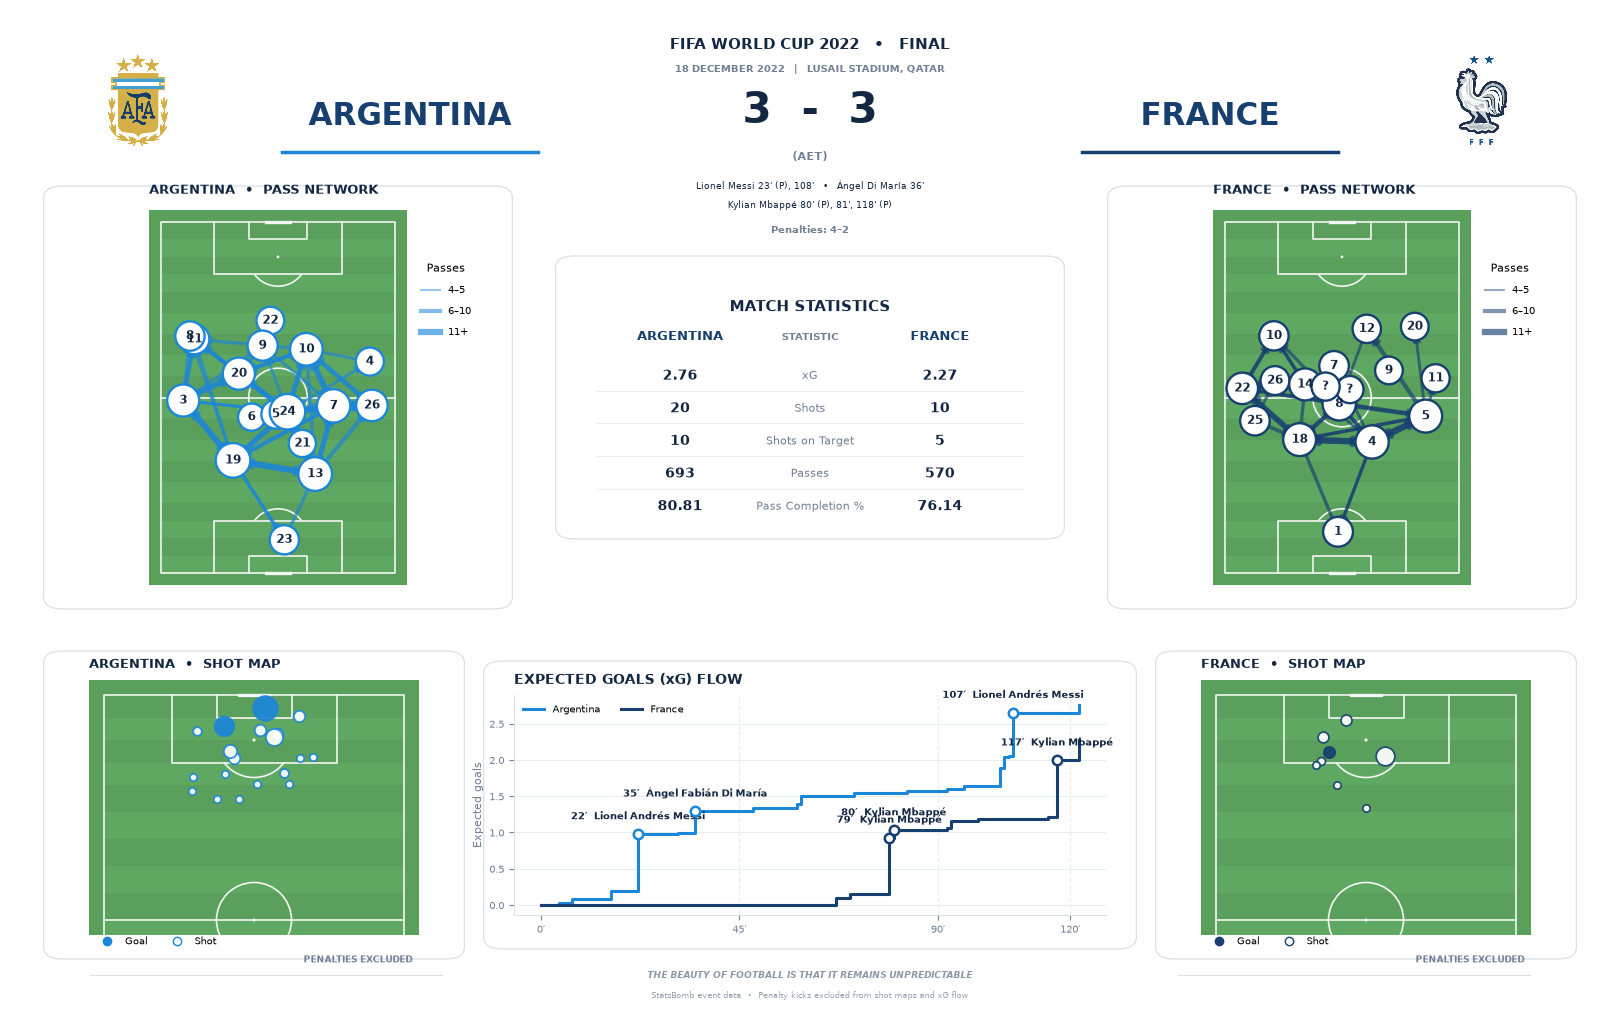

In [68]:
fig = create_dashboard(df, save_path="dashboard.png")